In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

In [16]:
uploaded = files.upload()

Saving Day5-Christ-College-ElectricBill_AC.xlsx to Day5-Christ-College-ElectricBill_AC (1).xlsx


In [17]:
df = pd.read_excel("Day5-Christ-College-ElectricBill_AC.xlsx")

display(df.head())

,No.,AC_Units,Electric_Bill (INR)
0,1,10,850
1,2,15,980
2,3,20,1150
3,4,25,1350
4,5,30,1600


In [18]:
print(df.columns)

Index(['No.', 'AC_Units', 'Electric_Bill (INR)'], dtype='object')


In [19]:
X = df[['AC_Units']]
y = df['Electric_Bill (INR)']

display(X.head())
display(y.head())

,AC_Units
0,10
1,15
2,20
3,25
4,30


,Electric_Bill (INR)
0,850
1,980
2,1150
3,1350
4,1600


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [21]:
model = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    LinearRegression()
)

model.fit(X_train, y_train)

Pipeline(steps=[('polynomialfeatures', PolynomialFeatures(include_bias=False)),
                ('linearregression', LinearRegression())])

In [22]:
y_pred = model.predict(X_test)

display(y_pred)

array([1016.00789392, 8750.01988532, 7107.6990732 , 1080.31668326])

In [23]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 68.51088392522976
MSE: 9420.33347672318
RMSE: 97.05840240145714
R2 Score: 0.9992539797443883


In [24]:
pred_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

display(pred_df)

,Actual,Predicted
0,850,1016.007894
17,8750,8750.019885
15,7100,7107.699073
1,980,1080.316683


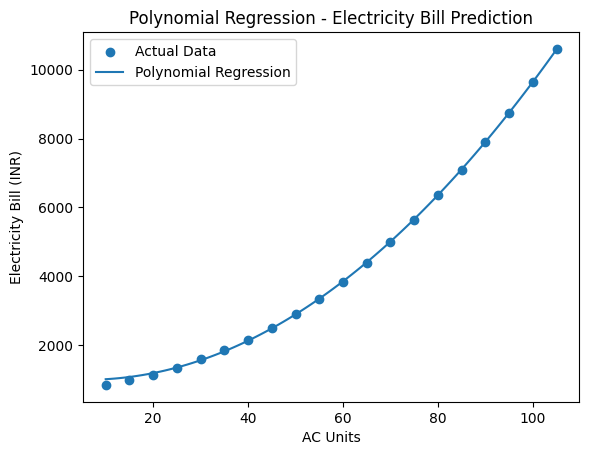

In [25]:
X_plot = pd.DataFrame({
    'AC_Units': np.linspace(
        X['AC_Units'].min(),
        X['AC_Units'].max(),
        100
    )
})

y_plot = model.predict(X_plot)

plt.scatter(X['AC_Units'], y, label="Actual Data")
plt.plot(X_plot['AC_Units'], y_plot, label="Polynomial Regression")

plt.xlabel("AC Units")
plt.ylabel("Electricity Bill (INR)")
plt.title("Polynomial Regression - Electricity Bill Prediction")

plt.legend()
plt.show()

In [26]:
joblib.dump(model, "electric_bill_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [27]:
files.download("electric_bill_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>